In [18]:
import torch

data = torch.load("../data/asoca_proj_128/32_projs/Diseased_07_lca.pt")

data.keys()

dict_keys(['ori_projs', 'label_projs', 'mask_2d', 'depth', 'ori_projs_meta', 'label_projs_meta', 'bg_mask', 'cl_mask', 'case_name', 'branch_type'])

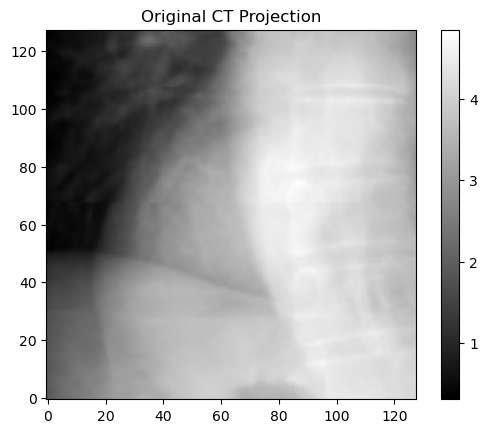

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
ori_projs = data["ori_projs"]
plt.imshow(ori_projs[0].T, origin="lower", cmap='gray')
plt.title("Original CT Projection")
plt.colorbar()
plt.show()

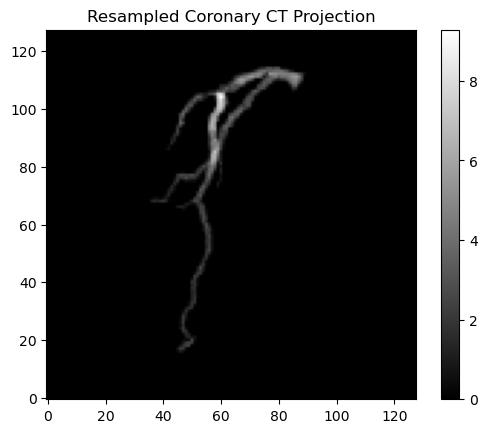

In [20]:
label_projs = data["label_projs"]
plt.imshow(label_projs[0].T, origin="lower", cmap='gray')
plt.title("Resampled Coronary CT Projection")
plt.colorbar()
plt.show()

对体积投影得到 ori_projs ($P_{body}$) 时，已经将 volume 中的值从 HU 转换为了 mu, 因此有：
$$
P_{body} = \int \mu_{body}(x) dx
$$

对于 label_projs ($P_{vessel}$)，由于 vessel 中的值为 1，其他地方为 0，因此有：
$$
P_{vessel} = \int m(x) dx,
$$
其中 $m(x)$ 是一个二值函数，在 vessel 区域为 1，其他区域为 0。

最后想得到的是 XCA-like 图像，即 vessel 区域的增强部分，其他区域的衰减部分。根据 Beer-Lambert 定律，投影图像的强度 $I$ 与入射强度 $I_0$ 和总的衰减系数成指数关系：
$$
\begin{align}
I   & = I_0 \exp(-\int \mu(x) dx) \\
    & = I_0 \exp(-\int \mu_{body}(x) dx - \mu_{iodine}\int m(x) dx) \\
    & = I_0 \exp(-P_{body} - \mu_{iodine} P_{vessel}) \\
\end{align}
$$

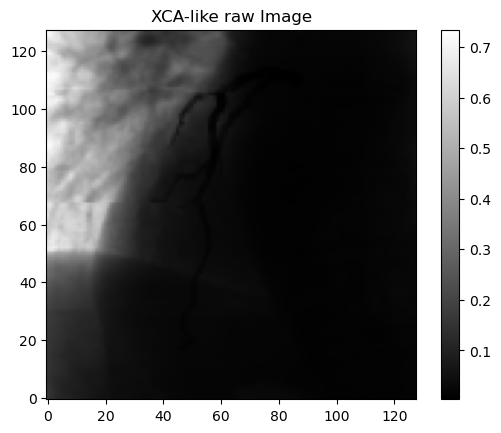

In [36]:
MU_IDODINE = 0.25

# # ~~这里需要乘以一个 0.1 才能得到比较好的可视化结果，可能来源于 ODL 对体素投影时丢失的尺度因子？或者是后处理参数？~~
# # 拿真实数据试了下，确实是后处理参数，效果类似于 exosure/gamma 
# xca = torch.exp(-0.1*(ori_projs + label_projs * MU_IDODINE)) # I/I0

# plt.imshow(xca[0].T, origin="lower", cmap='gray')
# plt.title("XCA-like raw Image")
# plt.colorbar()
# plt.show()

# 更正确的方法是先生成 raw data, 然后进行 gamma 矫正


xca_raw = torch.exp( - (ori_projs + label_projs * MU_IDODINE) ) # I/I0

plt.imshow(xca_raw[0].T, origin="lower", cmap='gray')
plt.title("XCA-like raw Image")
plt.colorbar()
plt.show()


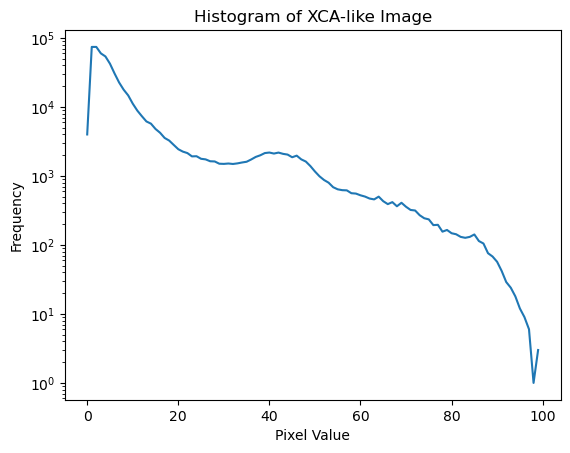

In [37]:
hist = torch.histc(xca_raw, bins=100, min=xca_raw.amin().item(), max=xca_raw.amax().item())
plt.plot(hist.numpy())
plt.yscale("log")
plt.title("Histogram of XCA-like Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

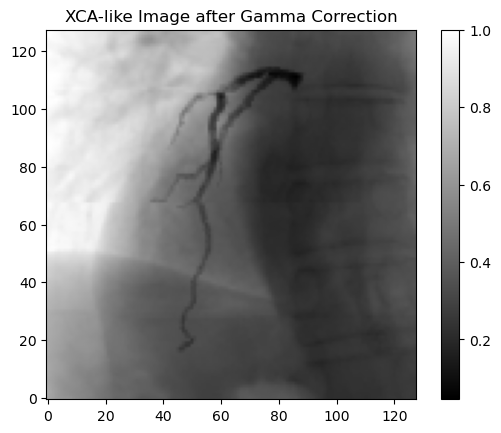

In [ ]:
xca_vis = torch.pow(xca_raw, 0.1)  # gamma correction

plt.imshow(xca_vis[0].T, origin="lower", cmap='gray')
plt.title("XCA-like Image after Gamma Correction")
plt.colorbar()
plt.show()